In [2]:
import matplotlib.pyplot as plt
import numpy as np
import jieba
from wordcloud import WordCloud
from PIL import Image
import pandas as pd
import jieba.analyse
from collections import Counter

C:\Users\WANG\AppData\Roaming\Python\Python313\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


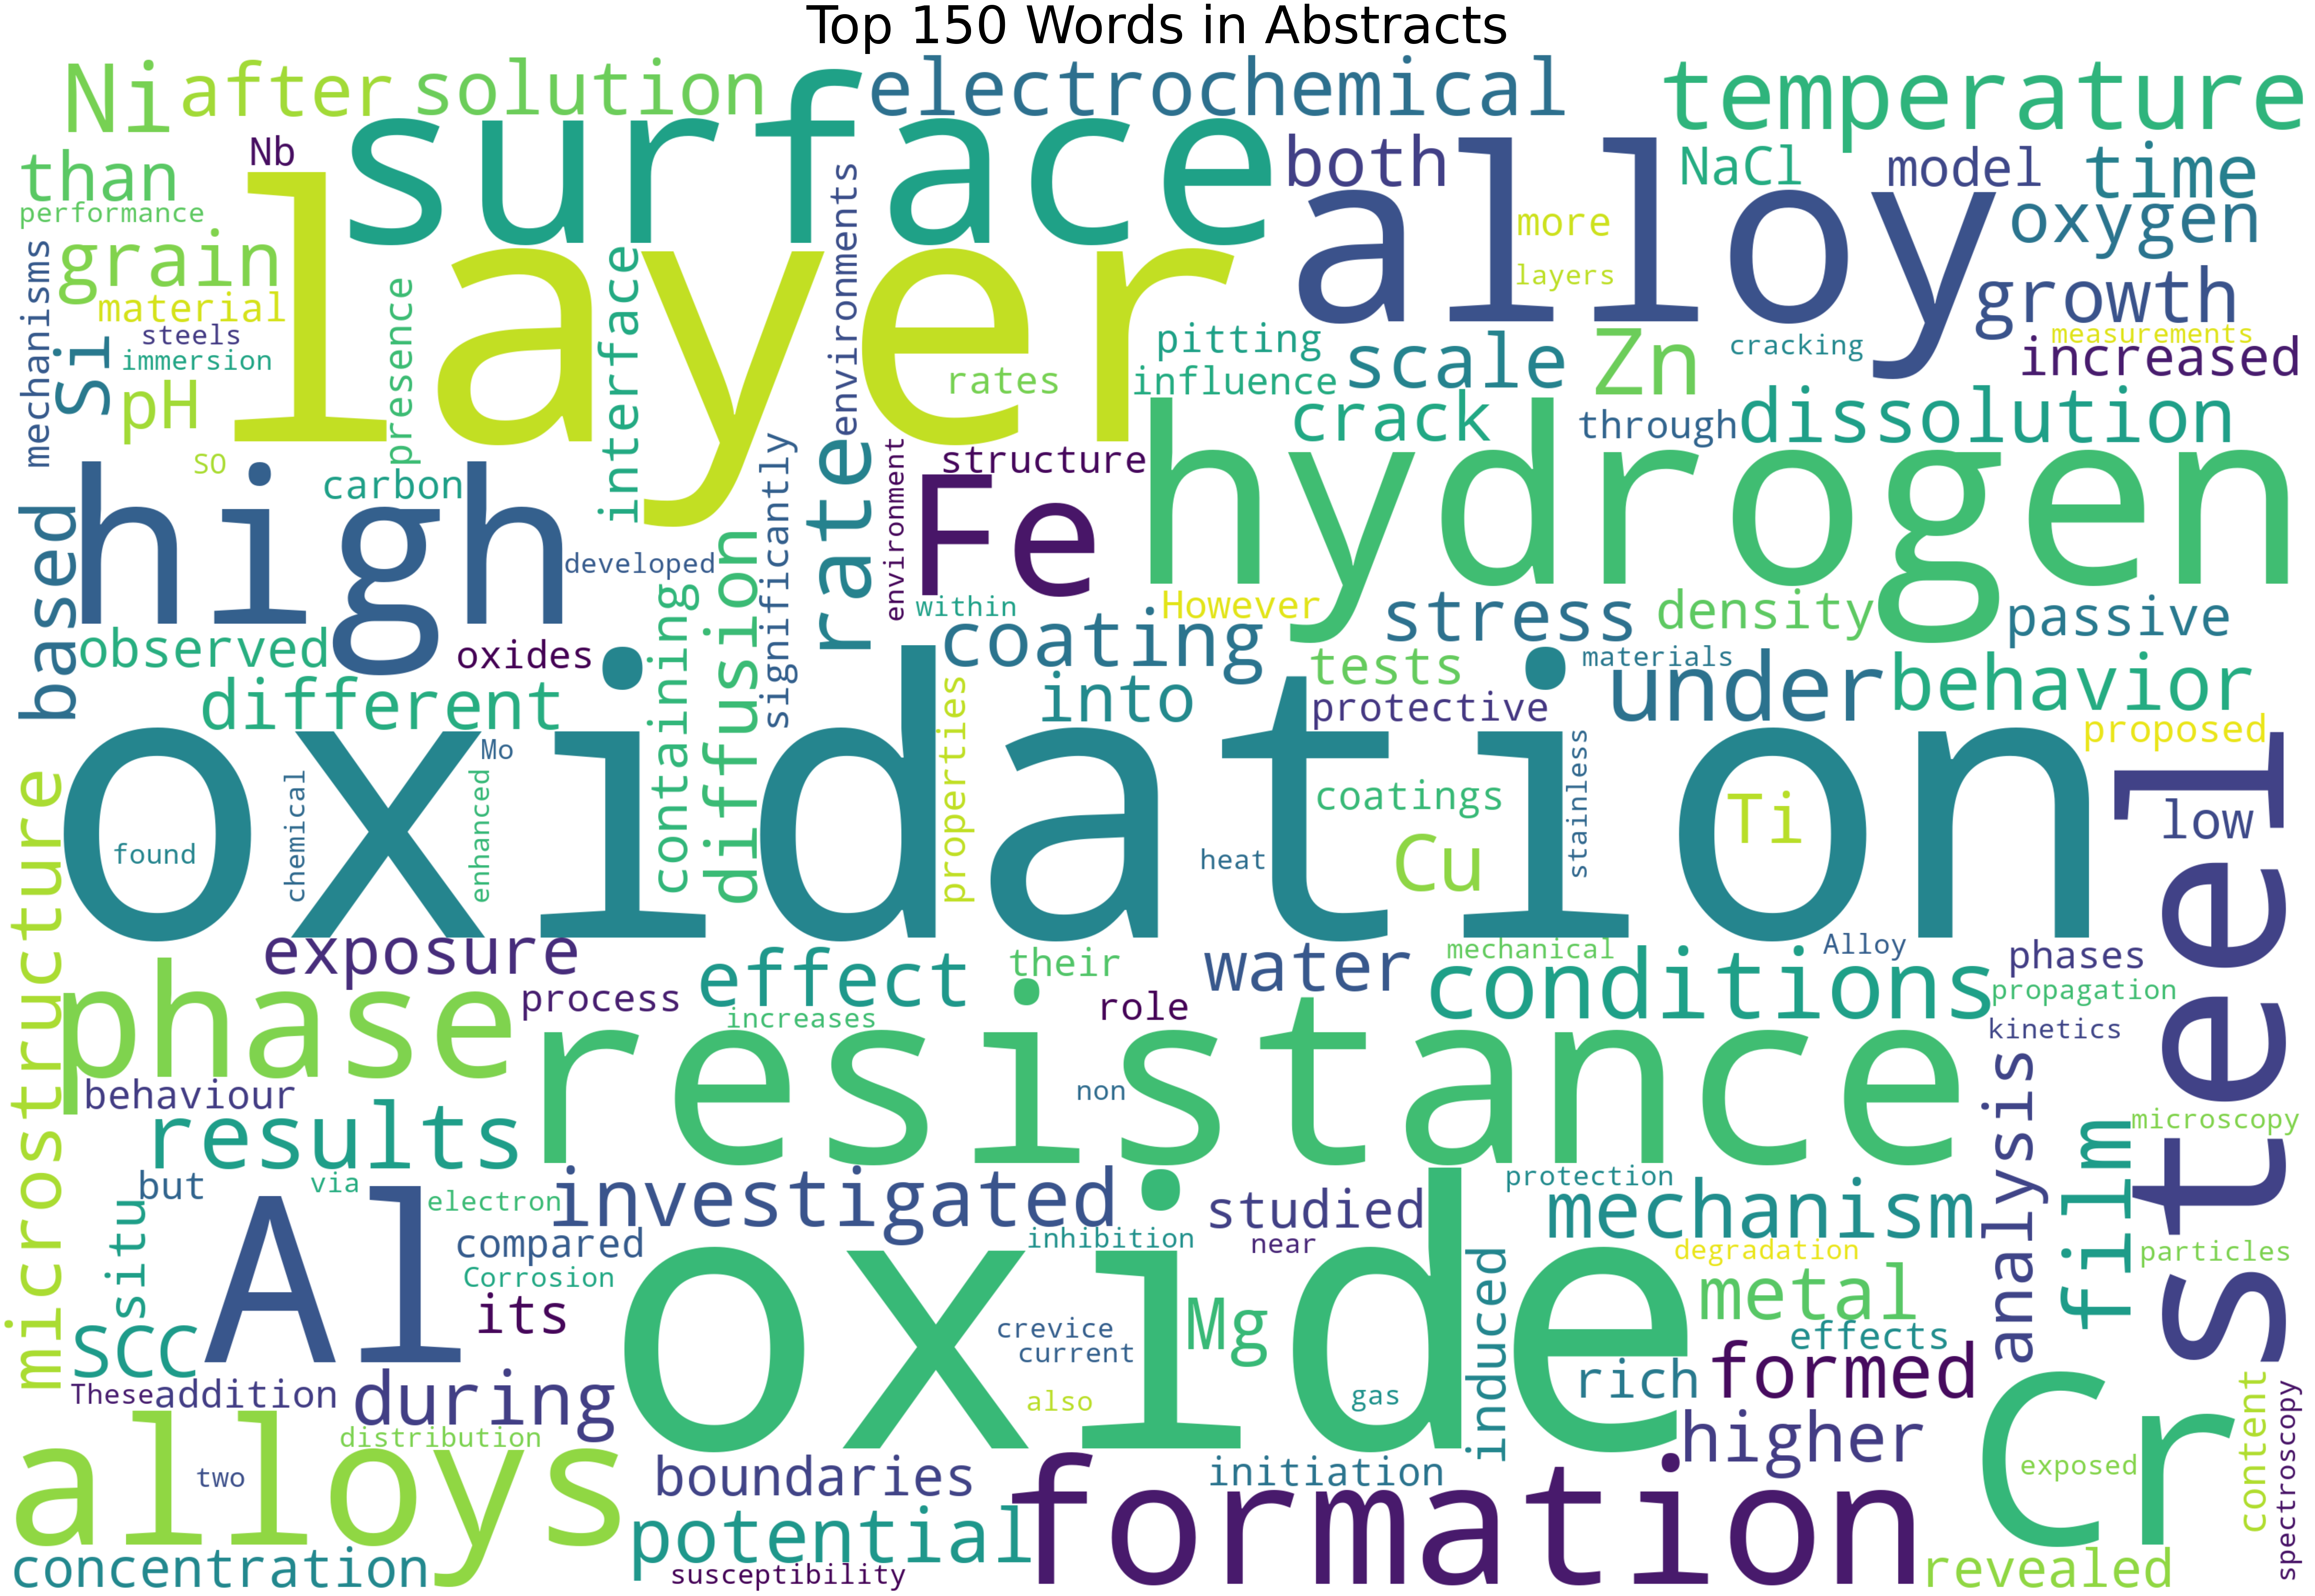

In [4]:
#提取摘要文本，进行分词
with open("dataset_with_abstract.csv",'r',encoding='utf-8') as f:
    df=pd.read_csv(f)#读取数据集
txt=" ".join(df["abstract"].dropna().astype(str))#将所有摘要文本合并成一个字符串
jieba.initialize()
wordlist=jieba.lcut(txt,cut_all=False)#分词
result_list=[]

#停用词表
stops=set()
with open('essential-word-list2.txt','r',encoding='utf-8') as f:
   con=f.readlines()
   for i in con:
       i=i.replace('\n','')#去掉换行符
       stops.add(i)

#过滤掉停用词和长度小于等于1的词喵
for word in wordlist:
    if word not in stops and len(word)>1:
        result_list.append(word)
keys=" ".join(result_list)#将过滤后的词列表合并成一个字符串
keywords=jieba.analyse.extract_tags(keys,topK=150,withWeight=True)#提取关键词，得到频次前150个 
top150_words=dict(keywords)

wc=WordCloud(background_color='white',width=3000,height=2000,max_words=200,stopwords=stops,max_font_size=500,random_state=75,collocations=False)
wc.generate_from_frequencies(top150_words)
plt.figure(figsize=(80,60))
plt.imshow(wc,interpolation='bilinear')
plt.axis('off')#隐藏坐标轴
plt.title("Top 150 Words in Abstracts",fontsize=100,pad=20)
plt.show()
wc.to_file("abstract_wordcloud.png")